In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
fiyatlar = []
isimler = []
verim = {
    "kitap ismi": isimler,
    "kitap fiyati": fiyatlar
}
url = "http://books.toscrape.com/"
cevap = requests.get(url)
soup = BeautifulSoup(cevap.content, "html.parser")
soup.title.text
bulunan_veriler = soup.find_all("p", class_="price_color")
for fiyat in bulunan_veriler:
    fiyatlar.append(fiyat.text)

In [3]:
print(f'toplam {len(fiyatlar)} veri bulundu.')

toplam 20 veri bulundu.


In [4]:
fiyatlar

['£51.77',
 '£53.74',
 '£50.10',
 '£47.82',
 '£54.23',
 '£22.65',
 '£33.34',
 '£17.93',
 '£22.60',
 '£52.15',
 '£13.99',
 '£20.66',
 '£17.46',
 '£52.29',
 '£35.02',
 '£57.25',
 '£23.88',
 '£37.59',
 '£51.33',
 '£45.17']

In [5]:
bulunan_veriler1 = soup.find_all("h3" )
bulunan_veriler1

[<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>,
 <h3><a href="catalogue/tipping-the-velvet_999/index.html" title="Tipping the Velvet">Tipping the Velvet</a></h3>,
 <h3><a href="catalogue/soumission_998/index.html" title="Soumission">Soumission</a></h3>,
 <h3><a href="catalogue/sharp-objects_997/index.html" title="Sharp Objects">Sharp Objects</a></h3>,
 <h3><a href="catalogue/sapiens-a-brief-history-of-humankind_996/index.html" title="Sapiens: A Brief History of Humankind">Sapiens: A Brief History ...</a></h3>,
 <h3><a href="catalogue/the-requiem-red_995/index.html" title="The Requiem Red">The Requiem Red</a></h3>,
 <h3><a href="catalogue/the-dirty-little-secrets-of-getting-your-dream-job_994/index.html" title="The Dirty Little Secrets of Getting Your Dream Job">The Dirty Little Secrets ...</a></h3>,
 <h3><a href="catalogue/the-coming-woman-a-novel-based-on-the-life-of-the-infamous-feminist-victoria-woodhull_993/ind

In [6]:
for isim in bulunan_veriler1:
    veri = isim.find("a")
    isimler.append(veri["title"])

yeniDataFrame = pd.DataFrame(verim)

In [7]:
yeniDataFrame

,kitap ismi,kitap fiyati
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23
5,The Requiem Red,£22.65
6,The Dirty Little Secrets of Getting Your Dream...,£33.34
7,The Coming Woman: A Novel Based on the Life of...,£17.93
8,The Boys in the Boat: Nine Americans and Their...,£22.60
9,The Black Maria,£52.15


In [8]:
yeniDataFrame.max()

kitap ismi      Tipping the Velvet
kitap fiyati                £57.25
dtype: object

In [9]:
yeniDataFrame.min()

kitap ismi      A Light in the Attic
kitap fiyati                  £13.99
dtype: object

In [10]:
yeniDataFrame['kitap fiyati'] = yeniDataFrame['kitap fiyati'].str.replace('£','')
yeniDataFrame['kitap fiyati'] = yeniDataFrame['kitap fiyati'].astype(float)
ortalama_fiyat = yeniDataFrame['kitap fiyati'].mean()
ortalama_fiyat

np.float64(38.048500000000004)

Text(0.5, 1.0, 'En Pahalidan Ucuza Kitap Fiyatlari')

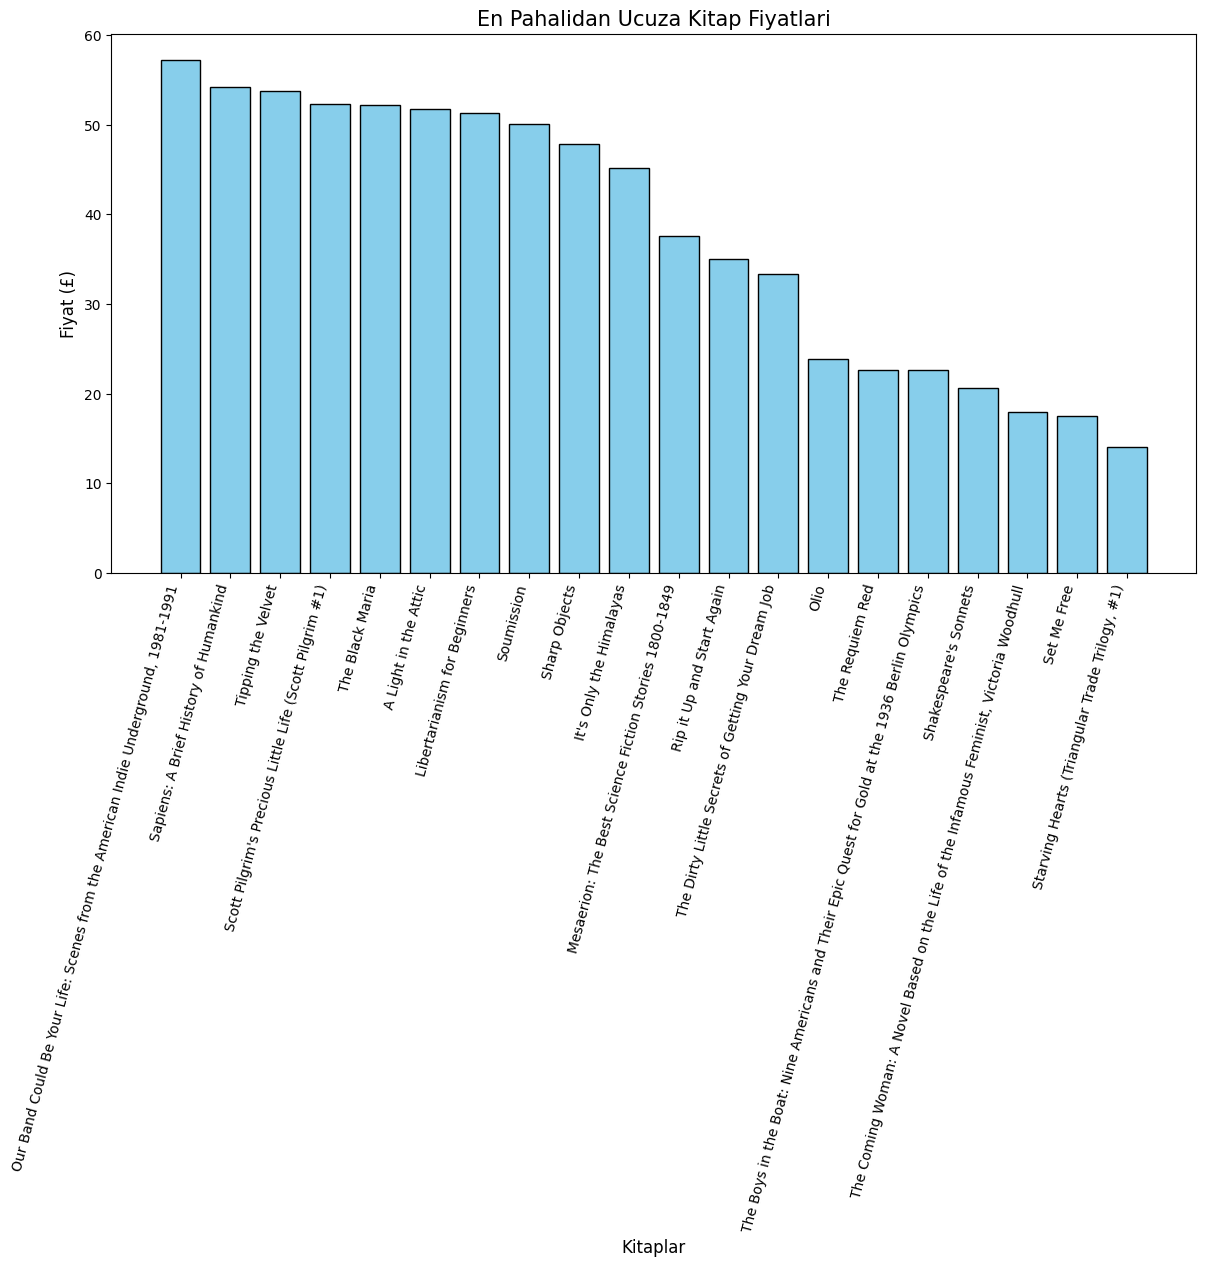

In [23]:
yeniDataFrame = yeniDataFrame.sort_values(by='kitap fiyati', ascending = False)

plt.figure(figsize=(14, 7))

plt.bar(yeniDataFrame['kitap ismi'],yeniDataFrame['kitap fiyati'],color = 'skyblue', edgecolor = 'black')
plt.xlabel('Kitaplar', fontsize= 12)
plt.ylabel('Fiyat (£)', fontsize= 12)
plt.xticks(rotation=75, ha='right') # Yazıları 75 derece yatır ve sağa yasla 

plt.title('En Pahalidan Ucuza Kitap Fiyatlari', fontsize= 15)

